### Import Necessary Packages and Libraries

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import joblib

In [2]:
# Read in csv
df = pd.read_csv('~/Desktop/ADA/ADA-final-project/data_ingestion/preprocessed_award_data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247241 entries, 0 to 247240
Data columns (total 36 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   internal_id                        247241 non-null  int64  
 1   Award ID_x                         247241 non-null  object 
 2   generated_internal_id              247241 non-null  object 
 3   Recipient Name                     247241 non-null  object 
 4   Recipient DUNS Number              19814 non-null   float64
 5   recipient_id                       246769 non-null  object 
 6   Award Amount                       247241 non-null  float64
 7   Awarding Agency                    247241 non-null  object 
 8   Awarding Sub Agency                247241 non-null  object 
 9   Funding Agency                     247241 non-null  object 
 10  Funding Sub Agency                 247241 non-null  object 
 11  Place of Performance City Code     0 no

# Predict Modification within 1 Year (Binary)

In [4]:
# Define columns for Machine Learning Processing
categorical_predictors = ['Awarding Agency' , 'Awarding Sub Agency', 'Funding Agency',
                         'Funding Sub Agency', 'Place of Performance Country Code', 'Place of Performance State Code',
                         'is_democrat', 'naics_code', 'start_year', 'award_not_fund_agency', 'award_not_fund_sub_agency'] # leave out psc_code (~ 900 values)
continuous_predictors = ['Award Amount', 'market_share']
target = 'overspend'
metadata = ['internal_id', 'Award ID_x', 'generated_internal_id', 'Recipient Name', 'recipient_id']

In [5]:
df = df[categorical_predictors + continuous_predictors + [target]]
df = df.dropna() # Only drops a few thousand records - insignificant comparatively

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 242266 entries, 0 to 247240
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Awarding Agency                    242266 non-null  object 
 1   Awarding Sub Agency                242266 non-null  object 
 2   Funding Agency                     242266 non-null  object 
 3   Funding Sub Agency                 242266 non-null  object 
 4   Place of Performance Country Code  242266 non-null  object 
 5   Place of Performance State Code    242266 non-null  object 
 6   is_democrat                        242266 non-null  int64  
 7   naics_code                         242266 non-null  float64
 8   start_year                         242266 non-null  float64
 9   award_not_fund_agency              242266 non-null  bool   
 10  award_not_fund_sub_agency          242266 non-null  bool   
 11  Award Amount                       242266 no

## Baseline Logistic Regression
### Run K Fold Cross Validation Grid Search

In [7]:
# We use handle_unknown='ignore' for OneHot so the model doesn't crash 
# if the test set has a brand new Agency or NAICS code.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_predictors),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_predictors)
    ])

# Create the Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
    ))
])

# Split Data
X = df[categorical_predictors + continuous_predictors]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Hyperparameters for Grid Search
# 'C' is inverse regularization strength (smaller = more regularization)
# 'penalty' defines L1 (Lasso) vs L2 (Ridge)
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
}

In [8]:
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='precision', 
    n_jobs=-1, 
    verbose=3 
    )

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Evaluation
y_pred_lr = grid_search.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_lr))

Starting Grid Search...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklea


Best Parameters: {'classifier__C': 0.01}
Best Cross-Validation Score: 0.0000

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.98      1.00      0.99     47669
        True       0.00      0.00      0.00       785

    accuracy                           0.98     48454
   macro avg       0.49      0.50      0.50     48454
weighted avg       0.97      0.98      0.98     48454



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


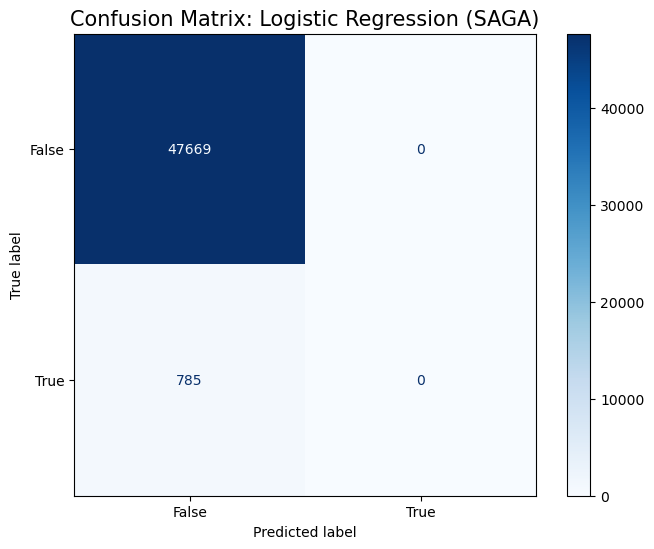

In [9]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search.classes_)

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix: Logistic Regression (SAGA)', fontsize=15)
plt.grid(False) # Clean up background lines
plt.show()

## Decision Tree

In [10]:
# Define the Decision Tree Pipeline
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Hyperparameters: focus on depth and leaf constraints to prevent overfitting
dt_param_grid = {
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 10, 20],
    'classifier__criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(dt_pipeline, dt_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose = 3)
dt_grid.fit(X_train, y_train)

print(f"Decision Tree Best Params: {dt_grid.best_params_}")

# Evaluation
y_pred_dt = dt_grid.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_dt))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Decision Tree Best Params: {'classifier__criterion': 'gini', 'classifier__max_depth': 30, 'classifier__min_samples_split': 2}

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.98      0.99      0.99     47669
        True       0.09      0.06      0.08       785

    accuracy                           0.97     48454
   macro avg       0.54      0.53      0.53     48454
weighted avg       0.97      0.97      0.97     48454



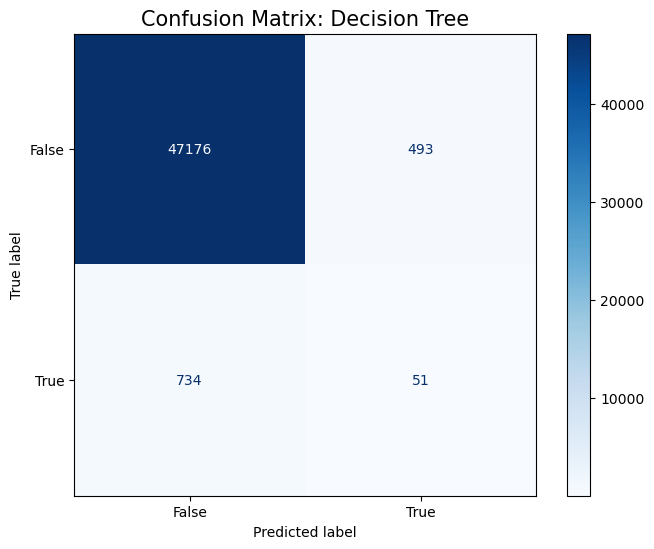

In [11]:
# Generate the confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=grid_search.classes_)

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix: Decision Tree', fontsize=15)
plt.grid(False) # Clean up background lines
plt.show()

## Random Forest

In [12]:
# Define the Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Hyperparameters: 'n_estimators' is the number of trees
rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"Random Forest Best Params: {rf_grid.best_params_}")

# Evaluation
y_pred_rf = rf_grid.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_rf))

[CV 3/5] END ...................classifier__C=1;, score=0.000 total time=   1.2s
[CV 4/5] END classifier__criterion=gini, classifier__max_depth=None, classifier__min_samples_split=2;, score=0.075 total time=  11.2s
[CV 5/5] END classifier__criterion=gini, classifier__max_depth=10, classifier__min_samples_split=10;, score=0.006 total time=   1.9s
[CV 3/5] END classifier__criterion=gini, classifier__max_depth=20, classifier__min_samples_split=10;, score=0.044 total time=   4.0s
[CV 3/5] END classifier__criterion=gini, classifier__max_depth=30, classifier__min_samples_split=10;, score=0.064 total time=   7.3s
[CV 3/5] END classifier__criterion=entropy, classifier__max_depth=None, classifier__min_samples_split=10;, score=0.076 total time=   9.1s
[CV 2/5] END classifier__criterion=entropy, classifier__max_depth=10, classifier__min_samples_split=10;, score=0.009 total time=   2.5s
[CV 2/5] END classifier__criterion=entropy, classifier__max_depth=20, classifier__min_samples_split=10;, score=0

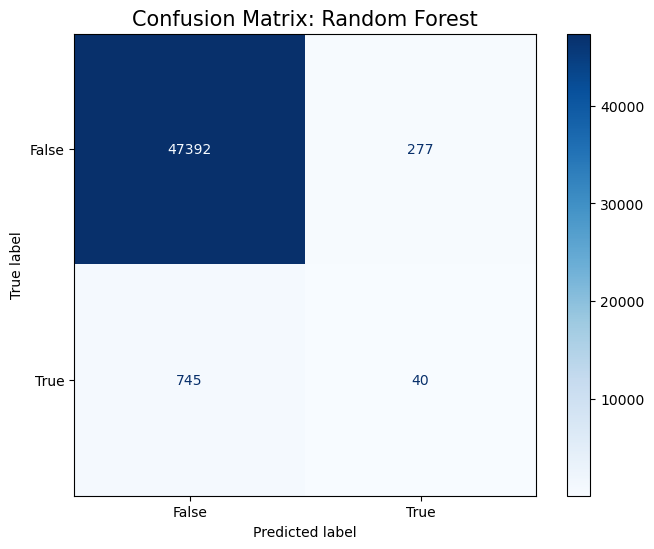

In [13]:
# Generate the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=grid_search.classes_)

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix: Random Forest', fontsize=15)
plt.grid(False) # Clean up background lines
plt.show()

## XGBoost

In [14]:
# Define the XGBoost Pipeline
# XGBoost handles its own weights, but likes the same preprocessed data
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# Hyperparameters: 'learning_rate' (eta) and 'n_estimators' are key
xgb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [3, 6, 9]
}

xgb_grid = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=5, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(f"XGBoost Best Params: {xgb_grid.best_params_}")

# Evaluation
y_pred_xgb = xgb_grid.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:53:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:53:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:53:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:53:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

XGBoost Best Params: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 9, 'classifier__n_estimators': 200}

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.98      1.00      0.99     47669
        True       0.40      0.01      0.01       785

    accuracy                           0.98     48454
   macro avg       0.69      0.50      0.50     48454
weighted avg       0.97      0.98      0.98     48454



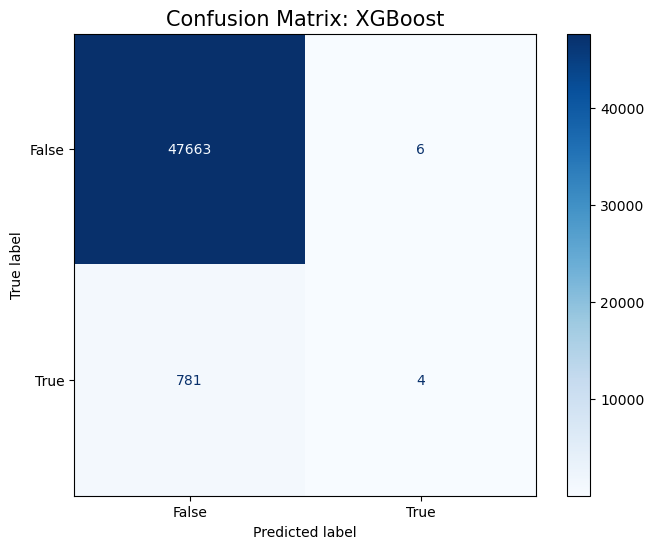

In [15]:
# Generate the confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=grid_search.classes_)

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix: XGBoost', fontsize=15)
plt.grid(False) # Clean up background lines
plt.show()

# Save Models and Metrics to Disk

In [17]:
version = "v1"

# IMPORTANT!!!!
## Ensure Proper Version Number above is specified before running!

In [23]:
# Dictionary to map your trained grid objects to filenames
model_dict = {
    "Logistic Regression": grid_search,
    "Decision Tree": dt_grid,
    "Random Forest": rf_grid,
    "XGBoost": xgb_grid
}

results_list = []

for name, grid in model_dict.items():
    # Save the model
    filename = f"models/overspend_{name.lower().replace(' ', '_')}_model_{version}.joblib"
    joblib.dump(grid.best_estimator_, filename)
    
    # Get predictions for evaluation
    y_pred = grid.predict(X_test)
    
    # Calculate metrics
    # We use classification_report output_dict=True to get all metrics easily
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results_list.append({
        "model_name": "overspend_" + name + "_" + version,
        "model_location": filename,
        "precision": report['True']['precision'],
        "recall": report['True']['recall'],
        "f1_score": report['True']['f1-score'],
        "weighted_avg_f1": report['weighted avg']['f1-score'],
        "macro_avg_f1": report['macro avg']['f1-score']
    })

# Create the summary CSV
df_metrics_old = pd.read_csv("over_base_model_evaluation_metrics.csv")

df_metrics = pd.concat([df_metrics_old, pd.DataFrame(results_list)], axis = 0)
df_metrics = df_metrics.drop_duplicates()

df_metrics.to_csv("over_base_model_evaluation_metrics.csv", index=False)

print("Models saved and metrics CSV generated successfully.")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Models saved and metrics CSV generated successfully.
